<a href="https://colab.research.google.com/github/KurniaYufi/sentiment-analysis-kematian-ali-khamenei/blob/main/pos-ner-tagging/article-pos-ner-tagging2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# POS Tagging & NER Berita Kematian Ali Khamenei - Detik

Notebook ini melakukan **Part-of-Speech (POS) Tagging** dan **Named Entity Recognition (NER)** pada data artikel berita dari Detik.com.

**Alur Notebook:**
1. Instalasi & Setup
2. Load Data
3. Validasi Data
4. POS Tagging + NER (satu pass, efisien)
5. Analisis Frekuensi POS
6. Visualisasi POS
7. Analisis & Visualisasi NER
8. Ekspor Hasil

**Perubahan utama dari versi sebelumnya:**
- Semua instalasi dipindahkan ke Section 1
- POS Tagging + NER diproses dalam **satu pass** (tidak duplikat komputasi)
- **NER diganti ke IndoBERT** (`cahya/bert-base-indonesian-NER`) karena Stanza tidak memiliki NER processor stabil untuk Bahasa Indonesia
- Analisis **lemma** ditambahkan agar kata berimbuhan dikelompokkan ke bentuk dasar
- `df_content` didefinisikan satu kali saja


## **(1) Instalasi & Setup**

Menginstal semua library yang dibutuhkan di **satu tempat**:
- **stanza** — POS Tagging + Lemmatisasi Bahasa Indonesia (IDN Treebank)
- **transformers / torch** — IndoBERT untuk NER
- **wordcloud / tqdm / matplotlib / seaborn** — visualisasi & progress bar


In [ ]:
# Install semua pustaka di satu tempat (dipindahkan dari tengah notebook)
!pip install stanza transformers torch tqdm matplotlib seaborn wordcloud --quiet


In [ ]:
import io
import warnings
import numpy as np
import pandas as pd
import stanza
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
from tqdm import tqdm
from wordcloud import WordCloud
from transformers import pipeline as hf_pipeline, AutoTokenizer, AutoModelForTokenClassification

warnings.filterwarnings('ignore')

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

tqdm.pandas(desc='Processing')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Semua pustaka berhasil diimpor.')
print(f'Mode: {"Google Colab" if IN_COLAB else "Lokal"}')


Semua pustaka berhasil diimpor.
Mode: Google Colab


## **(2) Load Data**

Memuat file CSV hasil preprocessed (`merged_articles.csv`). Kolom yang digunakan adalah **`text_cleaned`**.


In [ ]:
if IN_COLAB:
    uploaded = files.upload()
    fn = list(uploaded.keys())[0]
    try:
        df_article = pd.read_csv(io.BytesIO(uploaded[fn]))
        print(f'File "{fn}" berhasil dimuat — {df_article.shape[0]} baris, {df_article.shape[1]} kolom.')
    except Exception as e:
        raise ValueError(f'Gagal memuat CSV: {e}')
else:
    df_article = pd.read_csv('merged_articles.csv')
    print(f'Data lokal dimuat — {df_article.shape[0]} baris, {df_article.shape[1]} kolom.')


Saving article-preprocess.csv to article-preprocess.csv
File "article-preprocess.csv" berhasil dimuat — 491 baris, 13 kolom.


In [ ]:
print('Kolom tersedia:', df_article.columns.tolist())
df_article.head(5)


Kolom tersedia: ['News', 'url', 'title', 'content', 'text_cleaned', 'tokens', 'tokens_no_stop', 'text_no_stopwords', 'tokens_stemmed', 'text_final', 'polarity', 'subjectivity', 'sentiment_label']


,News,url,title,content,text_cleaned,tokens,tokens_no_stop,text_no_stopwords,tokens_stemmed,text_final,polarity,subjectivity,sentiment_label
0,Detik,https://news.detik.com/berita/d-8392835/puan-b...,Puan Berduka Ali Khamenei Gugur Diserang AS-Is...,Ketua DPR RI Puan Maharani menyampaikan dukaci...,ketua dpr ri puan maharani menyampaikan dukaci...,"['ketua', 'dpr', 'ri', 'puan', 'maharani', 'me...","['ketua', 'dpr', 'ri', 'puan', 'maharani', 'du...",ketua dpr ri puan maharani dukacita masyarakat...,"['ketua', 'dpr', 'ri', 'puan', 'maharani', 'du...",ketua dpr ri puan maharani dukacita masyarakat...,0.007451,0.210196,Netral
1,Detik,https://news.detik.com/internasional/d-8392814...,Trump Beri Sinyal Perang Lawan Iran Akan Selesai,Presiden Amerika Serikat (AS) Donald Trump men...,presiden amerika serikat as donald trump menga...,"['presiden', 'amerika', 'serikat', 'as', 'dona...","['presiden', 'amerika', 'serikat', 'as', 'dona...",presiden amerika serikat as donald trump peran...,"['presiden', 'amerika', 'serikat', 'as', 'dona...",presiden amerika serikat as donald trump peran...,0.149333,0.364000,Positive
2,Detik,https://www.detik.com/bali/berita/d-8392847/pe...,Peringatan Keras Iran ke Kapal Tanker yang Nek...,Ilyas Fadilah - detikBali\n\nHarga minyak duni...,ilyas fadilah detikbali harga minyak dunia mel...,"['ilyas', 'fadilah', 'detikbali', 'harga', 'mi...","['ilyas', 'fadilah', 'detikbali', 'harga', 'mi...",ilyas fadilah detikbali harga minyak dunia mel...,"['ilyas', 'fadilah', 'detikbali', 'harga', 'mi...",ilyas fadilah detikbali harga minyak dunia lon...,0.029412,0.452941,Netral
3,Detik,https://finance.detik.com/energi/d-8392622/ira...,Iran Beri Peringatan Keras Kapal Tanker yang M...,"Juru Bicara Kementerian Luar Negeri Iran, Esma...",juru bicara kementerian luar negeri iran esmai...,"['juru', 'bicara', 'kementerian', 'luar', 'neg...","['juru', 'bicara', 'kementerian', 'negeri', 'i...",juru bicara kementerian negeri iran esmail bag...,"['juru', 'bicara', 'menteri', 'negeri', 'iran'...",juru bicara menteri negeri iran esmail baghaei...,-0.031579,0.438158,Netral
4,Detik,https://finance.detik.com/energi/d-8392622/ira...,Iran Beri Peringatan Keras Kapal Tanker yang M...,"Juru Bicara Kementerian Luar Negeri Iran, Esma...",juru bicara kementerian luar negeri iran esmai...,"['juru', 'bicara', 'kementerian', 'luar', 'neg...","['juru', 'bicara', 'kementerian', 'negeri', 'i...",juru bicara kementerian negeri iran esmail bag...,"['juru', 'bicara', 'menteri', 'negeri', 'iran'...",juru bicara menteri negeri iran esmail baghaei...,-0.031579,0.438158,Netral


## **(3) Validasi Data**

Sebelum diproses, pastikan:
1. Kolom `text_cleaned` tersedia
2. Nilai NaN / teks kosong ditangani
3. Distribusi panjang teks aman


In [ ]:
assert 'text_no_stopwords' in df_article.columns, 'Kolom text_no_stopwords tidak ditemukan!'

n_missing = df_article['text_no_stopwords'].isna().sum()
if n_missing > 0:
    print(f'Peringatan: {n_missing} nilai NaN pada text_no_stopwords — diisi string kosong.')
    df_article['text_no_stopwords'] = df_article['text_no_stopwords'].fillna('')

df_article['text_no_stopwords'] = df_article['text_no_stopwords'].astype(str).str.strip()
n_empty = (df_article['text_no_stopwords'] == '').sum()
if n_empty > 0:
    print(f'Peringatan: {n_empty} baris teks kosong dihapus.')
    df_article = df_article[df_article['text_no_stopwords'] != ''].reset_index(drop=True)

df_article['text_length'] = df_article['text_no_stopwords'].str.split().str.len()
print(f'\nStatistik panjang teks (jumlah kata):')
print(df_article['text_length'].describe().round(1))
print(f'\nTotal artikel siap diproses: {len(df_article)}')


Statistik panjang teks (jumlah kata):
count    491.0
mean     198.7
std      109.7
min        4.0
25%      137.5
50%      177.0
75%      235.5
max      805.0
Name: text_length, dtype: float64

Total artikel siap diproses: 491


## **(4) POS Tagging + NER — Satu Pass**

### 4a. Inisialisasi Stanza (POS + Lemma)

Menggunakan **Stanza** model Bahasa Indonesia (Universal Dependencies / IDN Treebank) untuk POS tagging dan lemmatisasi.

| Tag | Kelas Kata | Contoh |
|-----|------------|--------|
| NOUN | Kata Benda | *pemimpin, negara* |
| VERB | Kata Kerja | *meninggal, menyatakan* |
| ADJ  | Kata Sifat | *tertinggi, resmi* |
| ADV  | Kata Keterangan | *kemarin, segera* |
| PROPN | Nama Diri | *Khamenei, Iran* |
| NUM  | Numeralia | *84, pertama* |
| PUNCT | Tanda Baca | `. , ?` |

> **Perbaikan:** Pipeline hanya diinisialisasi **satu kali** dengan processor `tokenize,pos,lemma`. Lemma digunakan pada analisis frekuensi agar kata berimbuhan (*meninggal*, *meninggalkan*, *ditinggal*) dikelompokkan ke bentuk dasarnya.

### 4b. Inisialisasi IndoBERT NER

**IndoBERT** (`cahya/bert-base-indonesian-NER`) adalah model BERT yang di-fine-tune khusus untuk NER Bahasa Indonesia:

| Label | Entitas | Contoh |
|-------|---------|--------|
| PER | Orang / Tokoh | *Ali Khamenei, Ebrahim Raisi* |
| ORG | Organisasi / Lembaga | *IRGC, PBB* |
| LOC | Lokasi Geografis | *Tehran, Indonesia* |


In [ ]:
# ── Stanza: POS + Lemma ──────────────────────────────────────────────
# FIX: Satu pipeline saja — tidak diinisialisasi dua kali
stanza.download('id', verbose=False)

stanza_nlp = stanza.Pipeline(
    'id',
    processors='tokenize,pos,lemma',  # NER Stanza id tidak tersedia
    tokenize_no_ssplit=False,
    verbose=False
)
print('[Stanza] Pipeline POS + Lemma siap.')

# ── IndoBERT: NER ─────────────────────────────────────────────────────
# FIX: Ganti dari Stanza (tidak support NER id) ke IndoBERT
# Model: cahya/bert-base-indonesian-NER
# Fine-tuned pada dataset NER Bahasa Indonesia (PER, ORG, LOC)
NER_MODEL = 'cahya/bert-base-indonesian-NER'

tokenizer_ner = AutoTokenizer.from_pretrained(NER_MODEL)
model_ner     = AutoModelForTokenClassification.from_pretrained(NER_MODEL)

ner_pipeline = hf_pipeline(
    'ner',
    model=model_ner,
    tokenizer=tokenizer_ner,
    aggregation_strategy='simple',  # gabung token B-/I- menjadi satu entitas utuh
    device=-1                        # CPU; ganti ke 0 jika tersedia GPU
)
print('[IndoBERT] NER pipeline siap.')


[Stanza] Pipeline POS + Lemma siap.


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/443M [00:00<?, ?B/s]

BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[IndoBERT] NER pipeline siap.


In [ ]:
# ── Fungsi ekstraksi SATU PASS (POS + Lemma + NER sekaligus) ────────
#
# FIX dari versi sebelumnya:
#   1. Tidak ada dua loop terpisah (get_pos_tags + get_ner_tags dipanggil
#      masing-masing) — sekarang satu fungsi, satu kali proses per artikel
#   2. Lemma diambil bersamaan dengan POS — tidak butuh pass tambahan
#   3. NER menggunakan IndoBERT yang benar-benar fungsional

def extract_pos_ner(text: str):
    """
    Memproses satu teks dan mengembalikan tuple:
      pos_tags  : list of (token, upos)
      lemma_tags: list of (lemma, upos)  — untuk analisis frekuensi berbasis lemma
      ner_tags  : list of (entity_text, entity_label)
    """
    if not text or not text.strip():
        return [], [], []

    # --- POS + Lemma via Stanza (satu doc object, dua hasil) ---
    doc        = stanza_nlp(text)
    pos_tags   = [(w.text,  w.upos) for sent in doc.sentences for w in sent.words]
    lemma_tags = [(w.lemma, w.upos) for sent in doc.sentences for w in sent.words]

    # --- NER via IndoBERT ---
    # Truncate agar tidak melebihi batas token BERT (512 sub-word tokens)
    text_trunc = text[:512]
    ner_raw    = ner_pipeline(text_trunc)
    ner_tags   = [(ent['word'], ent['entity_group']) for ent in ner_raw]

    return pos_tags, lemma_tags, ner_tags


# ── Terapkan ke seluruh dataset ─────────────────────────────────────
print('Memproses POS + Lemma + NER dalam satu pass per artikel...')
results = df_article['text_no_stopwords'].progress_apply(extract_pos_ner)

df_article['pos_tags']   = results.apply(lambda x: x[0])
df_article['lemma_tags'] = results.apply(lambda x: x[1])
df_article['ner_tags']   = results.apply(lambda x: x[2])

print(f'Selesai. {len(df_article)} artikel diproses.')

Memproses POS + Lemma + NER dalam satu pass per artikel...


Processing: 100%|██████████| 491/491 [38:35<00:00,  4.72s/it]

Selesai. 491 artikel diproses.


In [ ]:
df_article[['text_no_stopwords', 'pos_tags', 'lemma_tags', 'ner_tags']].head(5)

,text_no_stopwords,pos_tags,lemma_tags,ner_tags
0,ketua dpr ri puan maharani dukacita masyarakat...,"[(ketua, NOUN), (dpr, NOUN), (ri, PROPN), (pua...","[(ketua, NOUN), (dpr, NOUN), (ri, PROPN), (pua...","[(ketua dpr ri, NOR), (puan maharani, PER), (i..."
1,presiden amerika serikat as donald trump peran...,"[(presiden, NOUN), (amerika, PROPN), (serikat,...","[(presiden, NOUN), (amerika, PROPN), (serikat,...","[(presiden amerika serikat as, NOR), (donald t..."
2,ilyas fadilah detikbali harga minyak dunia mel...,"[(ilyas, NOUN), (fadi, NOUN), (lah, PART), (de...","[(ilyas, NOUN), (fadi, NOUN), (lah, PART), (de...","[(ilyas fadilah, PER), (detik, ORG), (minyak d..."
3,juru bicara kementerian negeri iran esmail bag...,"[(juru, NOUN), (bicara, NOUN), (kementerian, N...","[(juru, NOUN), (bicara, NOUN), (menteri, NOUN)...","[(juru bicara kementerian negeri iran, NOR), (..."
4,juru bicara kementerian negeri iran esmail bag...,"[(juru, NOUN), (bicara, NOUN), (kementerian, N...","[(juru, NOUN), (bicara, NOUN), (menteri, NOUN)...","[(juru bicara kementerian negeri iran, NOR), (..."


## **(5) Analisis Frekuensi POS**

Menganalisis distribusi kelas kata dan top-10 kata per kelas.
Tersedia dua perspektif:
- **Berbasis token asli** — frekuensi permukaan (kata apa adanya)
- **Berbasis lemma** — frekuensi bentuk dasar (lebih representatif secara linguistik)


In [ ]:
EXCLUDE_TAGS  = {'PUNCT', 'SYM', 'X'}
RELEVANT_TAGS = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN', 'NUM']

# ── Flatten token asli ──────────────────────────────────────────────
df_wpos = pd.DataFrame(
    [(w, t) for tags in df_article['pos_tags'] for w, t in tags],
    columns=['Kata', 'POS']
)

# ── Flatten lemma ───────────────────────────────────────────────────
df_lemma = pd.DataFrame(
    [(l, t) for tags in df_article['lemma_tags'] for l, t in tags],
    columns=['Lemma', 'POS']
)

# FIX: df_content didefinisikan SATU KALI di sini, tidak didefinisikan ulang di cell lain
df_content       = df_wpos[~df_wpos['POS'].isin(EXCLUDE_TAGS)].copy()
df_content_lemma = df_lemma[~df_lemma['POS'].isin(EXCLUDE_TAGS)].copy()

print(f'Total token    : {len(df_wpos):,}')
print(f'Token unik     : {df_wpos["Kata"].nunique():,}')
print(f'Lemma unik     : {df_lemma["Lemma"].nunique():,}')
print(f'Kelas POS unik : {df_wpos["POS"].nunique()}')
df_wpos.head(10)


Total token    : 100,600
Token unik     : 7,549
Lemma unik     : 5,859
Kelas POS unik : 14


,Kata,POS
0,ketua,NOUN
1,dpr,NOUN
2,ri,PROPN
3,puan,NOUN
4,maharani,NOUN
5,dukacita,NOUN
6,masyarakat,NOUN
7,iran,NOUN
8,konflik,NOUN
9,puan,NOUN


In [ ]:
summary_df = (
    df_wpos.groupby('POS')
    .agg(
        Jumlah_Token=('Kata', 'count'),
        Token_Unik=('Kata', 'nunique')
    )
    .sort_values('Jumlah_Token', ascending=False)
    .reset_index()
)
summary_df['Persentase_%'] = (
    summary_df['Jumlah_Token'] / summary_df['Jumlah_Token'].sum() * 100
).round(2)

print('Ringkasan Distribusi POS Tag:')
display(summary_df)

summary_df.to_csv('pos_tags_summary.csv', index=False)
print('Ringkasan disimpan ke pos_tags_summary.csv')


Ringkasan Distribusi POS Tag:


,POS,Jumlah_Token,Token_Unik,Persentase_%
0,NOUN,66331,5058,65.94
1,VERB,14822,1788,14.73
2,PROPN,6887,719,6.85
3,ADJ,6226,485,6.19
4,PRON,1932,7,1.92
5,X,1143,260,1.14
6,PUNCT,913,20,0.91
7,PART,894,4,0.89
8,ADP,495,50,0.49
9,DET,387,12,0.38


Ringkasan disimpan ke pos_tags_summary.csv


In [ ]:
TOP_N = 10

top_words_per_pos = {}  # berbasis token asli — dipakai di visualisasi
top_lemma_per_pos = {}  # berbasis lemma      — lebih representatif

for tag in RELEVANT_TAGS:
    subset_token = df_content[df_content['POS'] == tag]
    subset_lemma = df_content_lemma[df_content_lemma['POS'] == tag]

    if not subset_token.empty:
        top_words_per_pos[tag] = subset_token['Kata'].value_counts().head(TOP_N)

    if not subset_lemma.empty:
        top_lemma_per_pos[tag] = subset_lemma['Lemma'].value_counts().head(TOP_N)
        print(f'\nTop {TOP_N} [{tag}] — Lemma:')
        print(top_lemma_per_pos[tag].to_string())



Top 10 [NOUN] — Lemma:
Lemma
iran        4778
khamenei    2646
serang      1823
pimpin      1431
israel      1233
ali         1094
ayatol       706
perintah     605
teheran      584
negara       568

Top 10 [VERB] — Lemma:
Lemma
tewas      805
milik      258
pilih      246
tinggal    228
ambil      200
lancar     195
serang     177
umum       158
bunuh      157
tulis      149

Top 10 [ADJ] — Lemma:
Lemma
tinggi           1168
militer           699
keras             230
resmi             208
nasional          201
salah             195
internasional     143
langsung          113
utama             105
penuh              91

Top 10 [ADV] — Lemma:
Lemma
langsung       27
berulang       22
coba           17
enggan         12
seraya         10
jarang          9
kuatmengapa     9
sepenuhnya      8
relatif         8
diduga          7

Top 10 [PROPN] — Lemma:
Lemma
as         1105
amerika     785
serikat     373
trump       329
israel      258
ali         163
to          138
al          125
don

## **(6) Visualisasi Distribusi POS**


In [ ]:
POS_COLORS = {
    'NOUN' : '#2196F3',
    'VERB' : '#4CAF50',
    'PROPN': '#FF9800',
    'ADJ'  : '#9C27B0',
    'ADV'  : '#F44336',
    'NUM'  : '#009688',
    'DET'  : '#795548',
    'ADP'  : '#607D8B',
    'CCONJ': '#E91E63',
    'PUNCT': '#9E9E9E',
    'SYM'  : '#BDBDBD',
    'X'    : '#EEEEEE',
}

def pos_color(tag):
    return POS_COLORS.get(tag, '#CFD8DC')


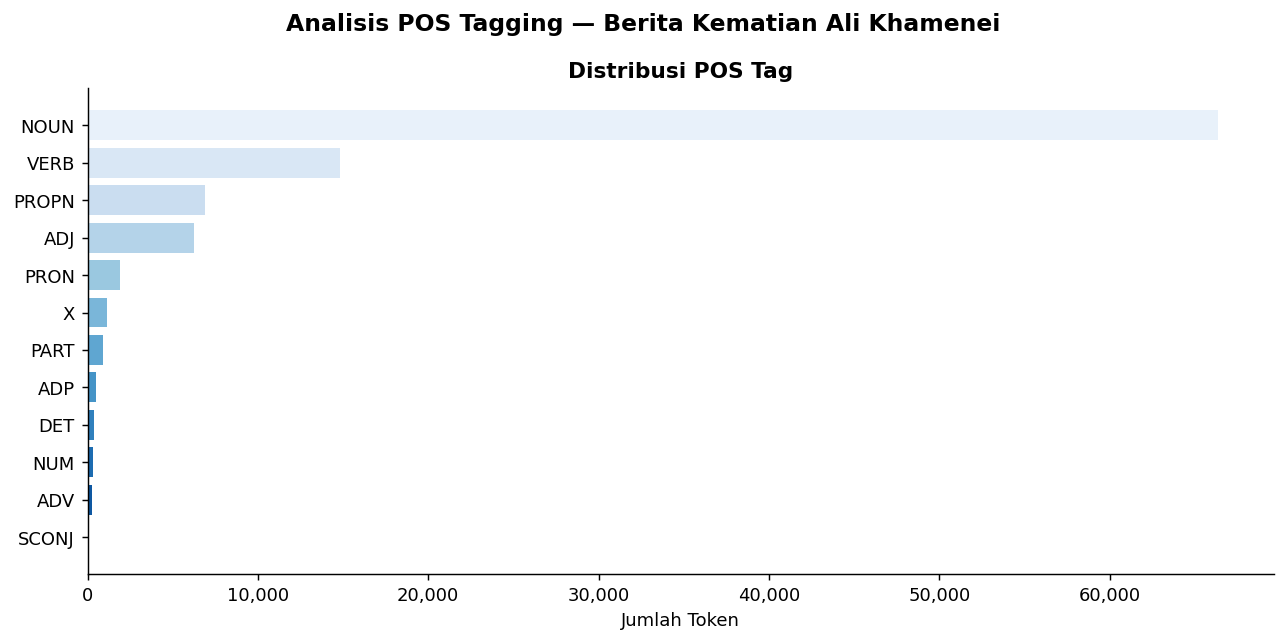

Grafik disimpan ke pos_distribution.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_df = summary_df[~summary_df['POS'].isin({'PUNCT', 'SYM'})].head(12)
palette = sns.color_palette('Blues_r', len(plot_df))
ax.barh(plot_df['POS'][::-1], plot_df['Jumlah_Token'][::-1], color=palette)
ax.set_xlabel('Jumlah Token')
ax.set_title('Distribusi POS Tag', fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Analisis POS Tagging — Berita Kematian Ali Khamenei', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pos_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan ke pos_distribution.png')


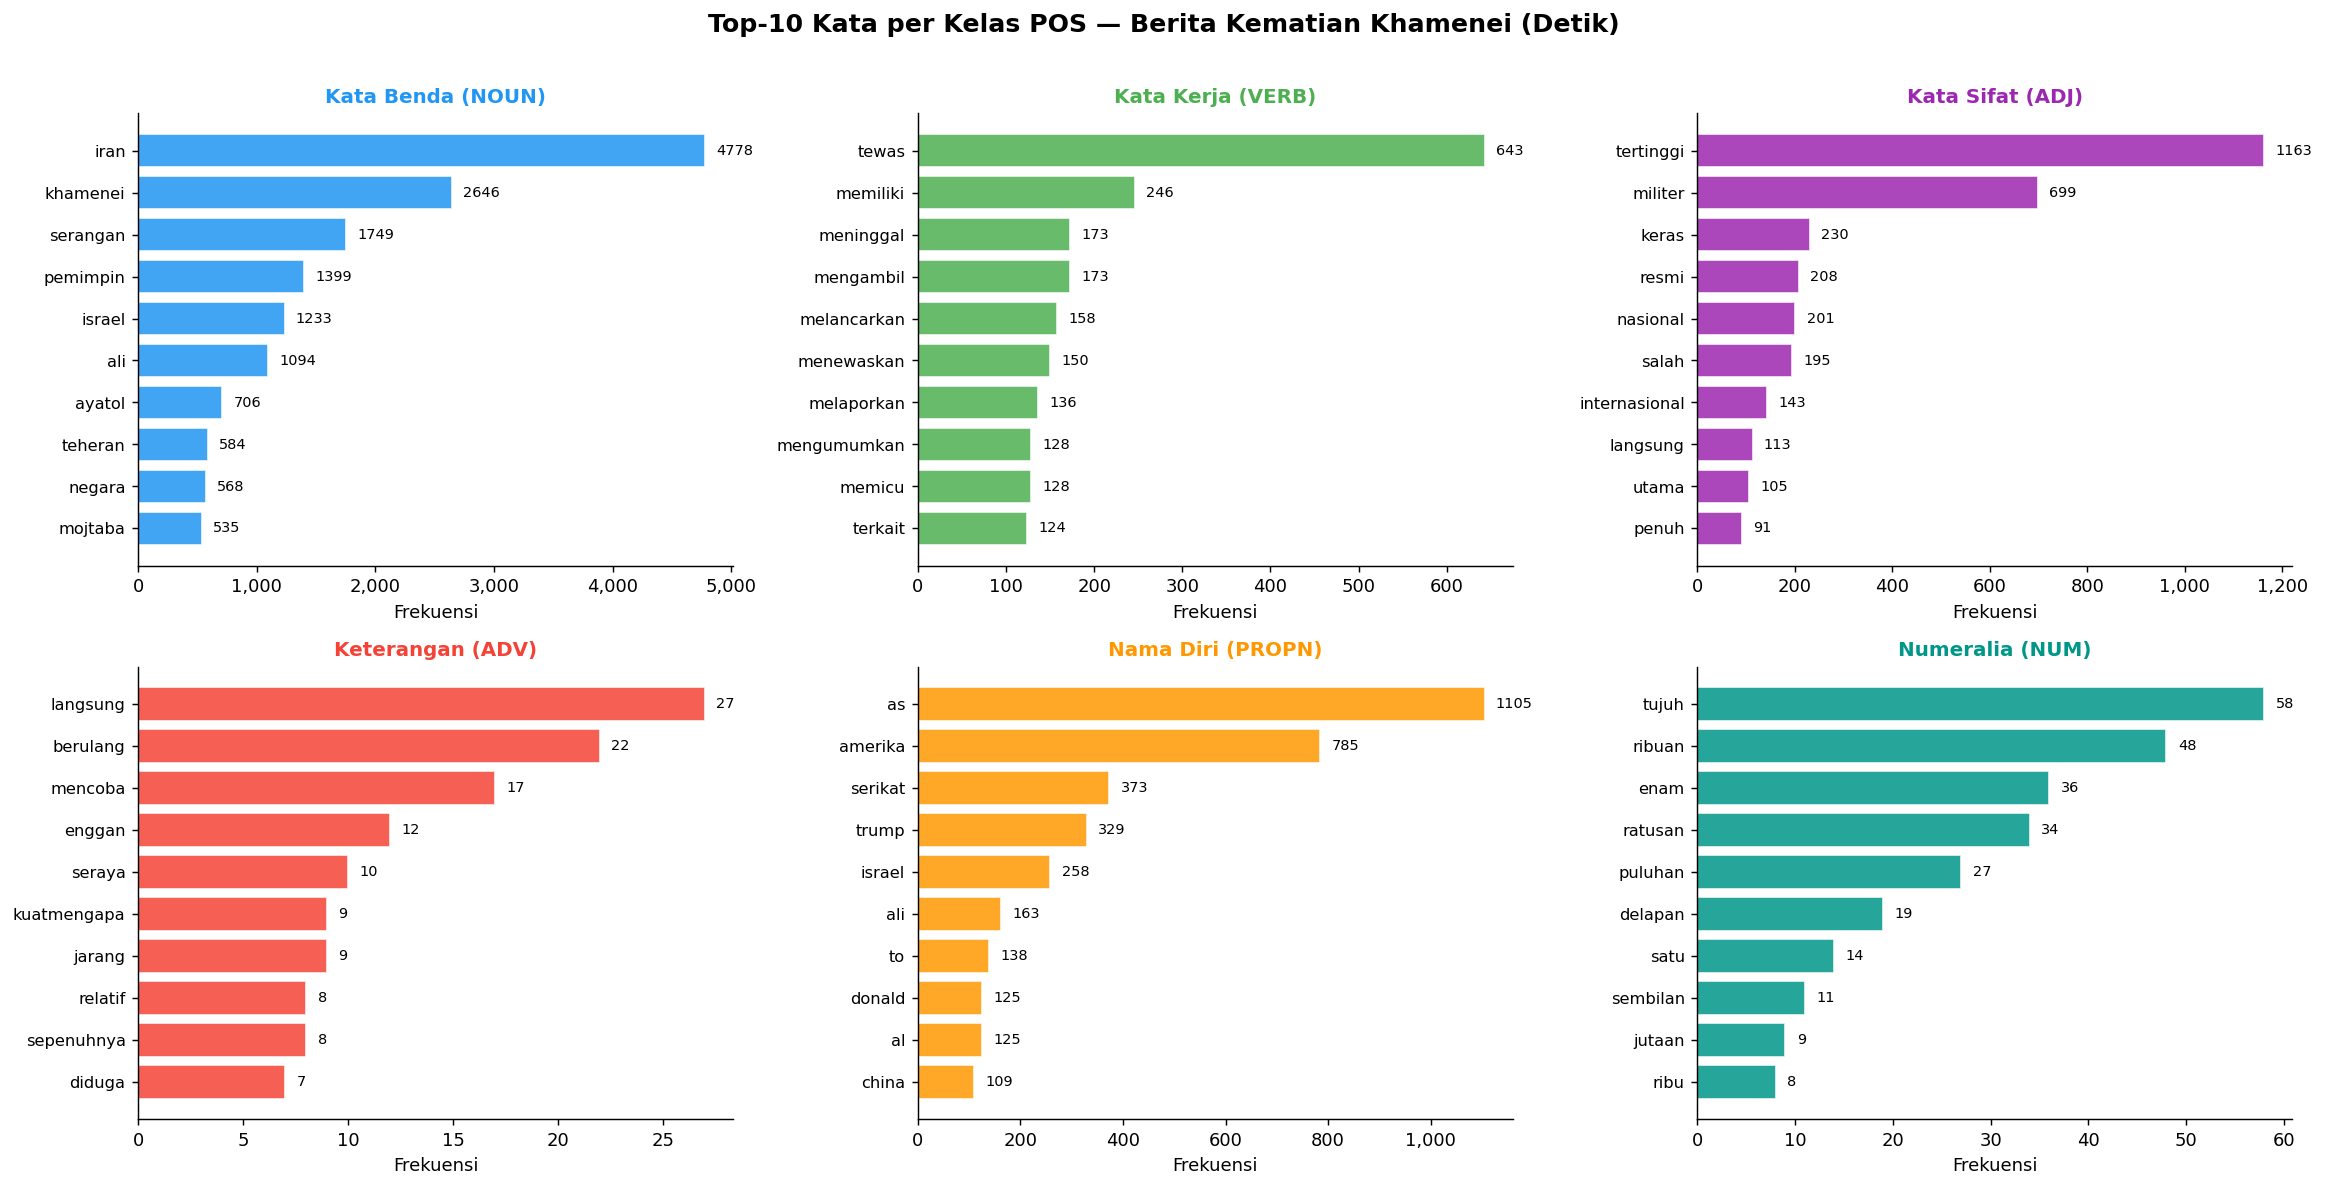

In [ ]:
# Top-10 kata (token asli) per kelas POS
tags_to_plot = [t for t in RELEVANT_TAGS if t in top_words_per_pos]
ncols = 3
nrows = -(-len(tags_to_plot) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4.5))
axes = axes.flatten()

tag_labels = {
    'NOUN': 'Kata Benda (NOUN)', 'VERB': 'Kata Kerja (VERB)',
    'PROPN': 'Nama Diri (PROPN)', 'ADJ': 'Kata Sifat (ADJ)',
    'ADV': 'Keterangan (ADV)', 'NUM': 'Numeralia (NUM)'
}

for i, tag in enumerate(tags_to_plot):
    ax = axes[i]
    data  = top_words_per_pos[tag].head(TOP_N).sort_values()
    color = pos_color(tag)
    bars  = ax.barh(data.index, data.values, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, data.values):
        ax.text(val + data.values.max() * 0.02,
                bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=8)
    ax.set_title(tag_labels.get(tag, tag), fontweight='bold', color=color, fontsize=11)
    ax.set_xlabel('Frekuensi')
    ax.tick_params(axis='y', labelsize=9)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for j in range(len(tags_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top-10 Kata per Kelas POS — Berita Kematian Khamenei (Detik)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_top10_per_pos.png', dpi=150, bbox_inches='tight')
plt.show()


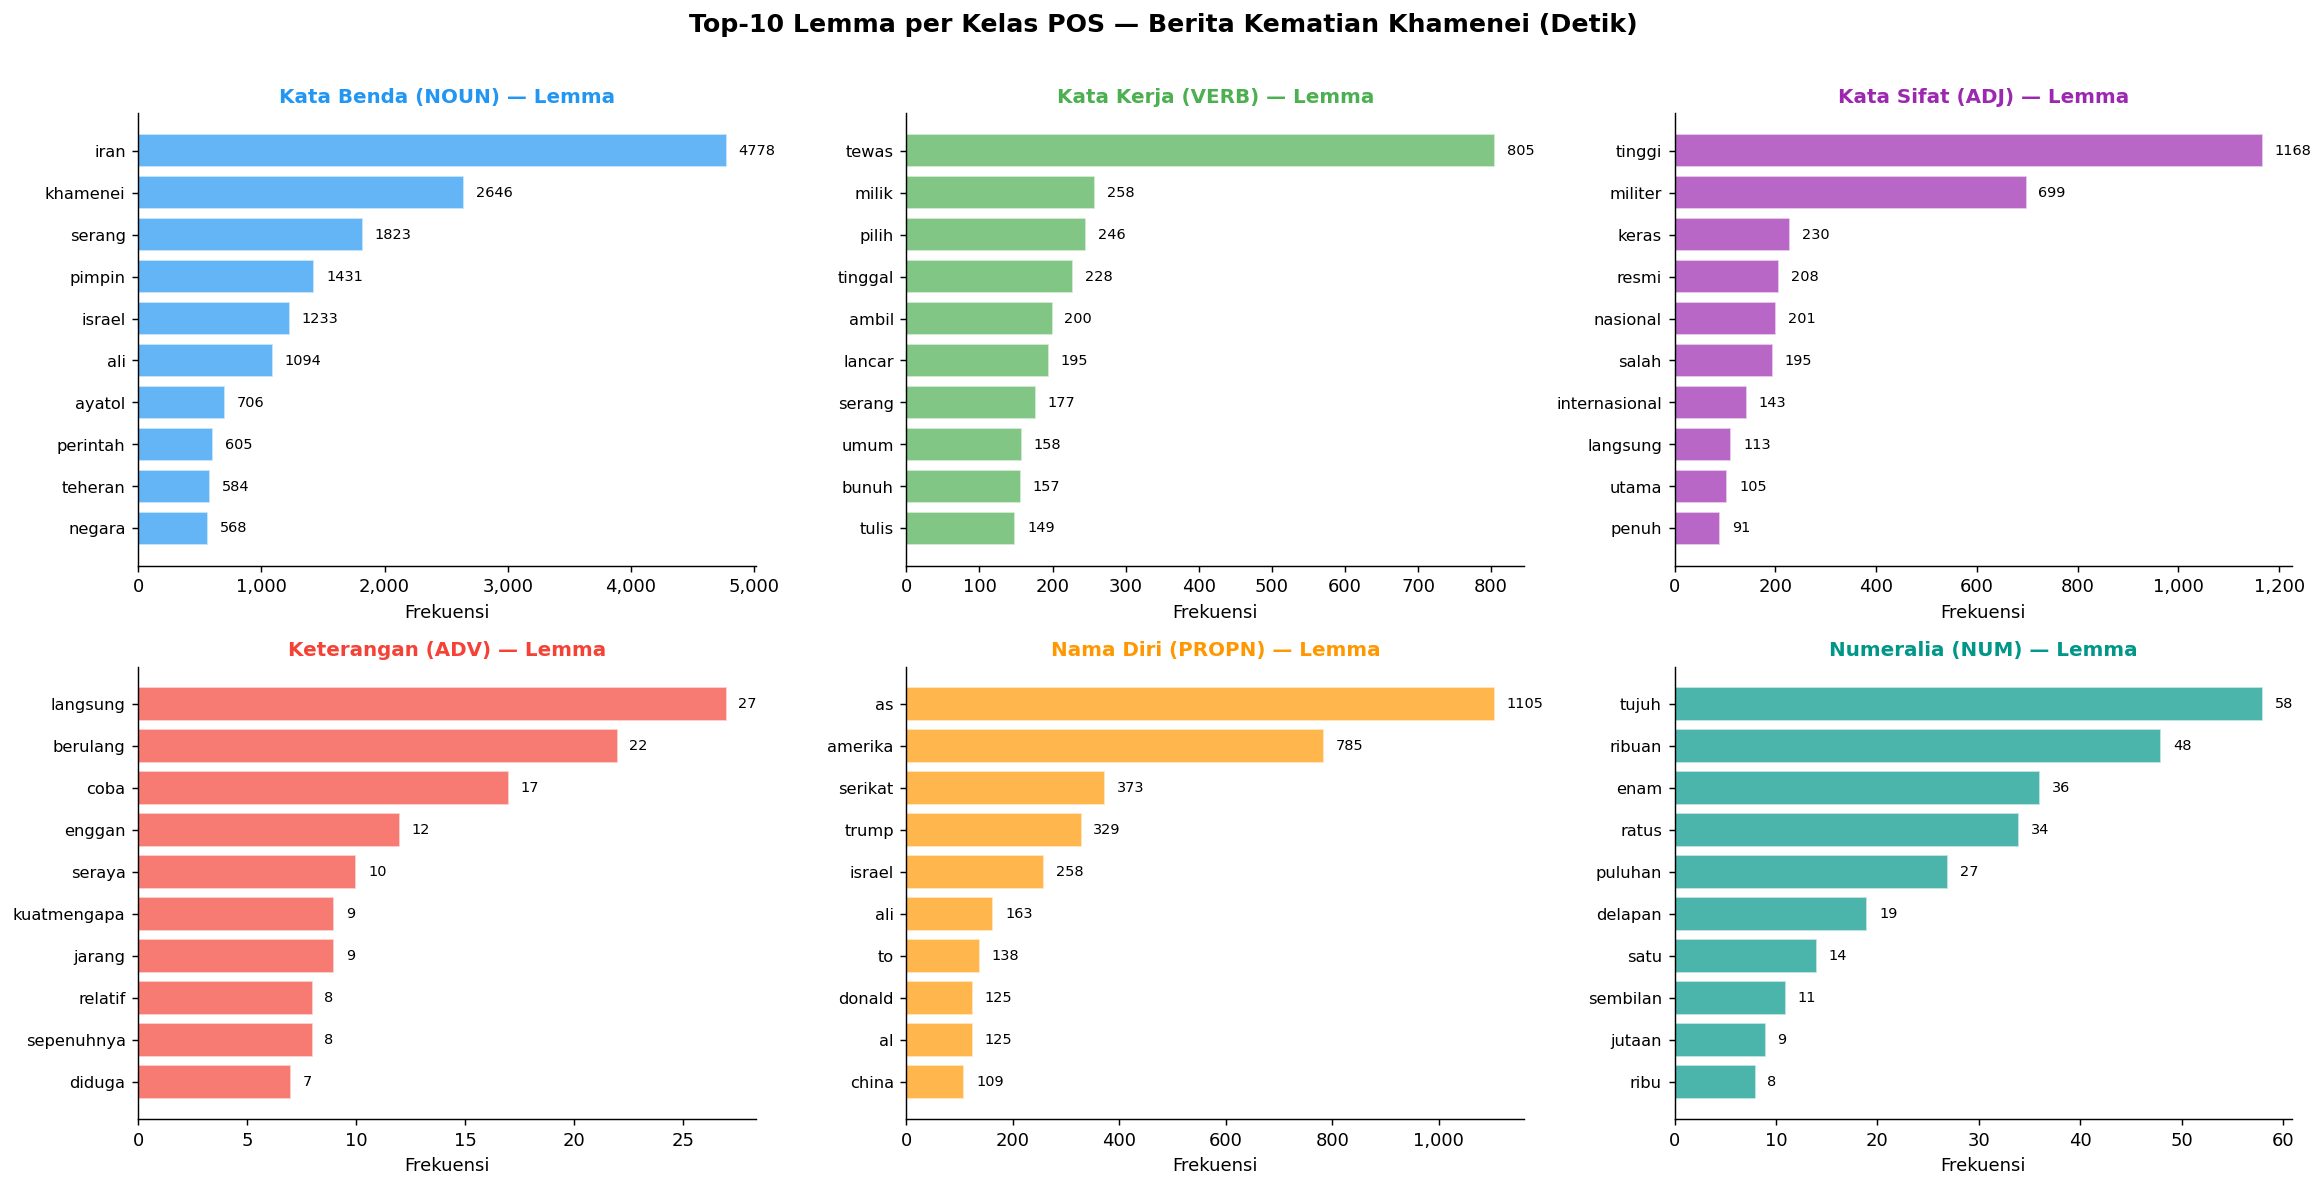

In [ ]:
# Top-10 LEMMA per kelas POS (lebih representatif secara linguistik)
tags_to_plot_l = [t for t in RELEVANT_TAGS if t in top_lemma_per_pos]
nrows_l = -(-len(tags_to_plot_l) // ncols)

fig, axes = plt.subplots(nrows_l, ncols, figsize=(18, nrows_l * 4.5))
axes = axes.flatten()

for i, tag in enumerate(tags_to_plot_l):
    ax = axes[i]
    data  = top_lemma_per_pos[tag].head(TOP_N).sort_values()
    color = pos_color(tag)
    bars  = ax.barh(data.index, data.values, color=color, alpha=0.7, edgecolor='white')
    for bar, val in zip(bars, data.values):
        ax.text(val + data.values.max() * 0.02,
                bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=8)
    ax.set_title(f"{tag_labels.get(tag, tag)} — Lemma",
                 fontweight='bold', color=color, fontsize=11)
    ax.set_xlabel('Frekuensi')
    ax.tick_params(axis='y', labelsize=9)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for j in range(len(tags_to_plot_l), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top-10 Lemma per Kelas POS — Berita Kematian Khamenei (Detik)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_top10_per_pos_lemma.png', dpi=150, bbox_inches='tight')
plt.show()


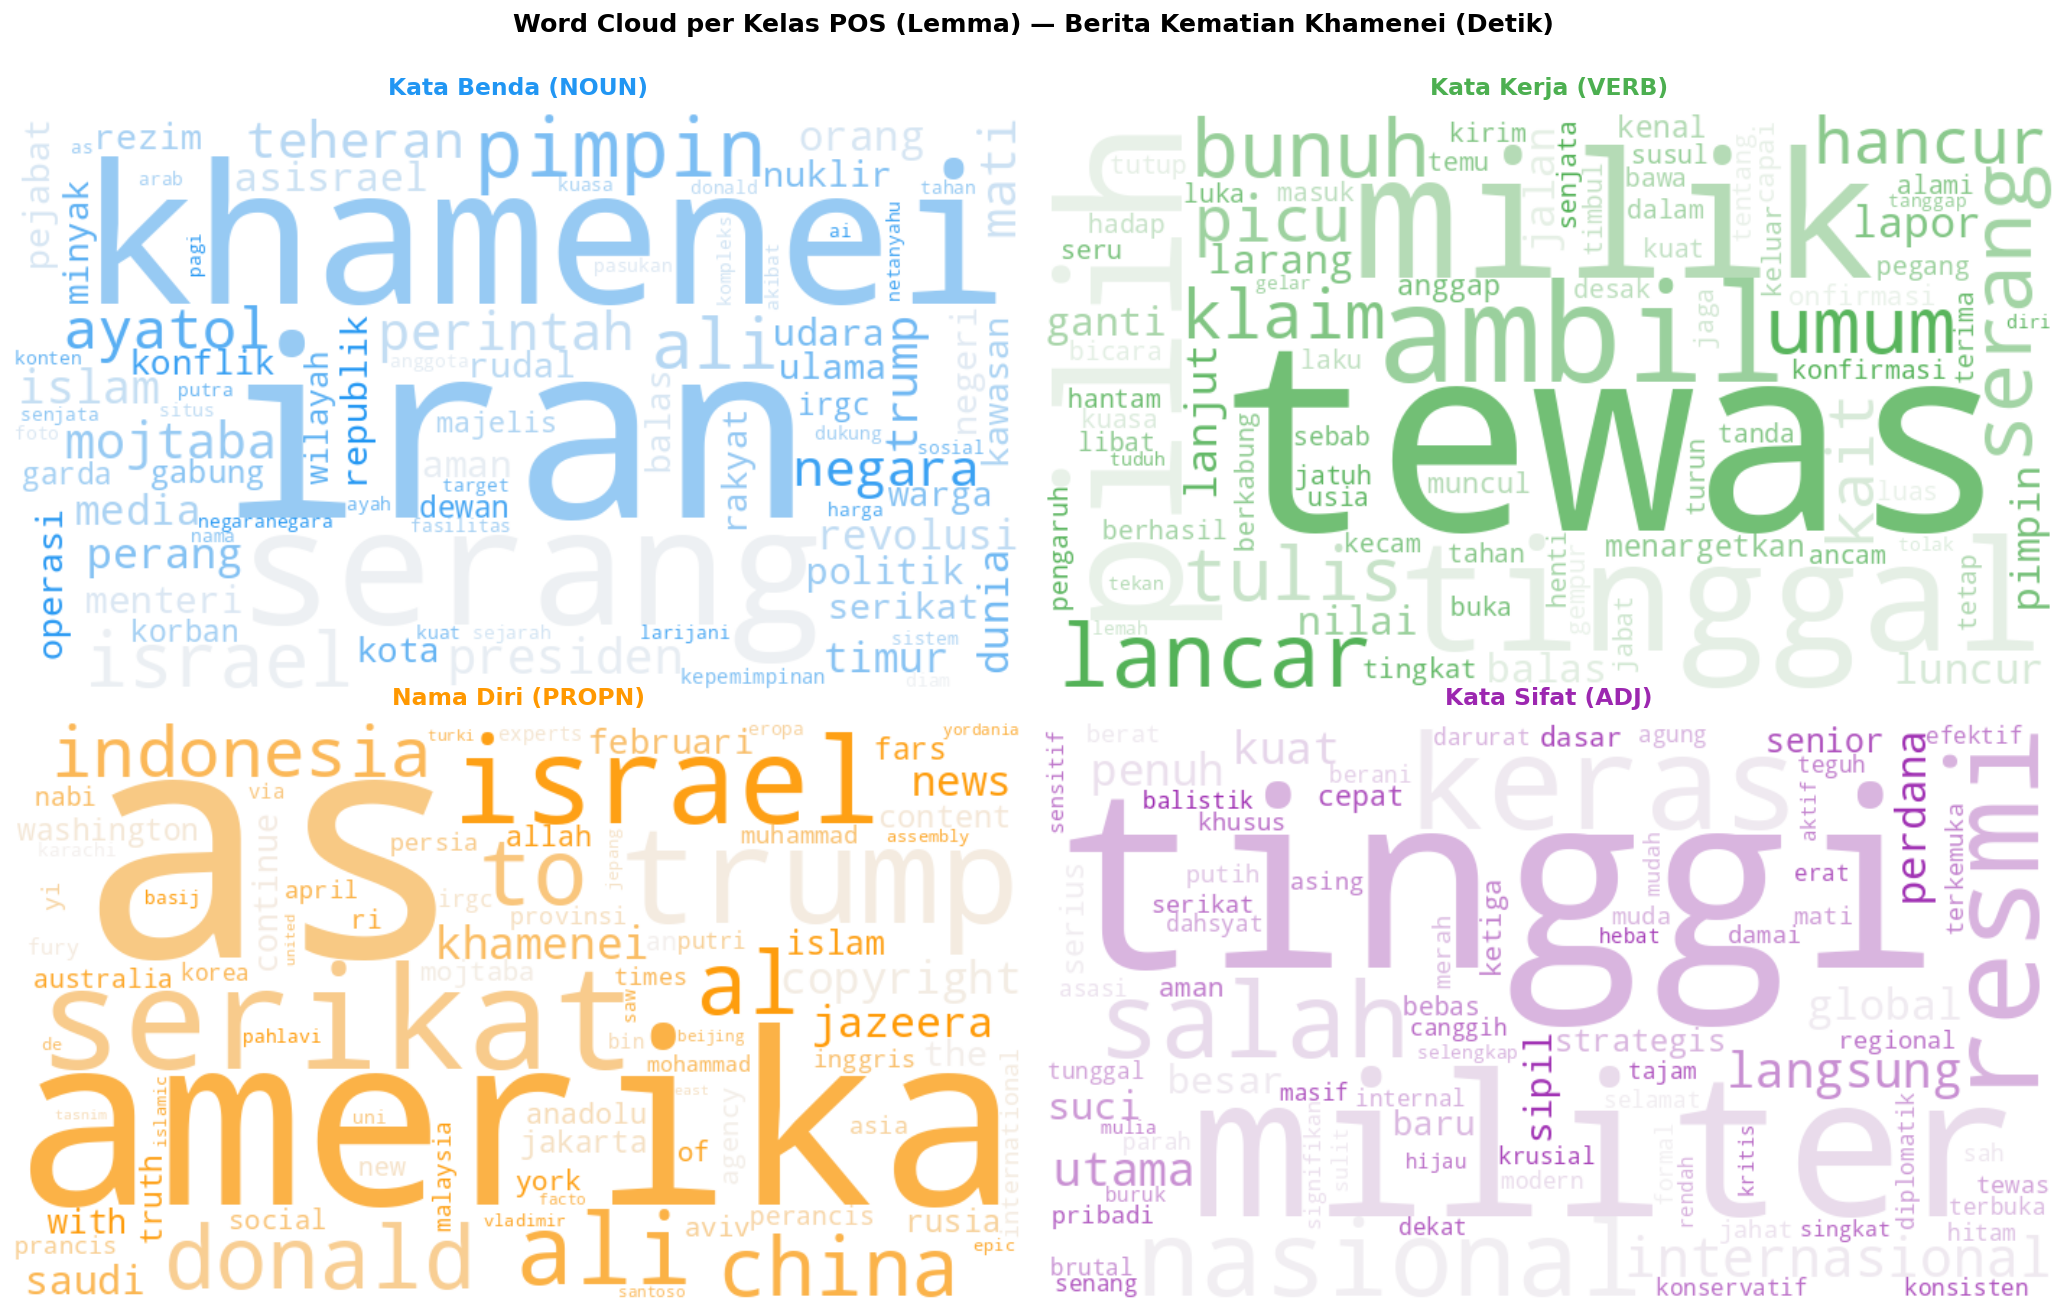

In [ ]:
# Word Cloud berbasis LEMMA (bukan token mentah seperti versi sebelumnya)
wc_tags   = ['NOUN', 'VERB', 'PROPN', 'ADJ']
wc_labels = {
    'NOUN': 'Kata Benda (NOUN)', 'VERB': 'Kata Kerja (VERB)',
    'PROPN': 'Nama Diri (PROPN)', 'ADJ': 'Kata Sifat (ADJ)',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, tag in enumerate(wc_tags):
    ax = axes[i]
    freq_dict = dict(df_content_lemma[df_content_lemma['POS'] == tag]['Lemma'].value_counts())
    if not freq_dict:
        ax.set_visible(False)
        continue
    base_color = pos_color(tag).lstrip('#')
    r, g, b = tuple(int(base_color[j:j+2], 16) for j in (0, 2, 4))
    colormap  = sns.light_palette((r/255, g/255, b/255), as_cmap=True, input='rgb')
    wc = WordCloud(
        width=700, height=400, background_color='white',
        colormap=colormap, max_words=80,
        prefer_horizontal=0.85, collocations=False,
    ).generate_from_frequencies(freq_dict)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(wc_labels[tag], fontsize=13, fontweight='bold',
                 color=pos_color(tag), pad=10)

plt.suptitle('Word Cloud per Kelas POS (Lemma) — Berita Kematian Khamenei (Detik)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_wordcloud_lemma.png', dpi=150, bbox_inches='tight')
plt.show()


## **(7) Analisis & Visualisasi NER**

### IndoBERT NER (`cahya/bert-base-indonesian-NER`)

NER sudah dijalankan bersamaan dengan POS tagging di Section 4 (satu pass). Cell ini hanya melakukan **analisis dan visualisasi** dari hasil yang sudah ada di `df_article['ner_tags']`.

**Label yang dihasilkan IndoBERT:**

| Label | Entitas | Contoh |
|-------|---------|--------|
| PER | Orang / Tokoh | *Ali Khamenei, Ebrahim Raisi* |
| ORG | Organisasi | *IRGC, PBB* |
| LOC | Lokasi | *Tehran, Indonesia* |


In [ ]:
# ── Flatten semua entitas ke satu DataFrame ──────────────────────────
df_ner = pd.DataFrame(
    [(e, t) for tags in df_article['ner_tags'] for e, t in tags],
    columns=['Entitas', 'Label']
)

# Bersihkan artefak tokenisasi BERT (strip spasi, hapus string kosong)
df_ner['Entitas'] = df_ner['Entitas'].str.strip()
df_ner = df_ner[df_ner['Entitas'] != ''].reset_index(drop=True)

print(f'Total entitas terdeteksi : {len(df_ner):,}')
print(f'Entitas unik             : {df_ner["Entitas"].nunique():,}')
print(f'Tipe entitas unik        : {df_ner["Label"].nunique()}')
df_ner.head(10)


Total entitas terdeteksi : 8,003
Entitas unik             : 2,098
Tipe entitas unik        : 19


,Entitas,Label
0,ketua dpr ri,NOR
1,puan maharani,PER
2,iran,GPE
3,puan duka,PER
4,pemimpin iran,NOR
5,ayatollah ali khamenei pu,PER
6,sidang persidangan iv,EVT
7,kompleks parlemen senayan jakarta,LOC
8,iran,GPE
9,amerika serikat,GPE


In [ ]:
ner_summary = (
    df_ner.groupby('Label')
    .agg(
        Jumlah_Entitas=('Entitas', 'count'),
        Entitas_Unik=('Entitas', 'nunique')
    )
    .sort_values('Jumlah_Entitas', ascending=False)
    .reset_index()
)
ner_summary['Persentase_%'] = (
    ner_summary['Jumlah_Entitas'] / ner_summary['Jumlah_Entitas'].sum() * 100
).round(2)

print('Ringkasan Distribusi Label NER:')
display(ner_summary)

TOP_N_ENT = 10
for label in ner_summary['Label']:
    subset = df_ner[df_ner['Label'] == label]
    top    = subset['Entitas'].value_counts().head(TOP_N_ENT)
    print(f'\nTop {TOP_N_ENT} [{label}]:')
    print(top.to_string())


Ringkasan Distribusi Label NER:


,Label,Jumlah_Entitas,Entitas_Unik,Persentase_%
0,GPE,2583,210,32.28
1,PER,2110,574,26.37
2,NOR,1764,658,22.04
3,ORG,551,350,6.88
4,PRD,276,169,3.45
5,LOC,177,135,2.21
6,EVT,176,137,2.20
7,REG,141,51,1.76
8,DAT,83,14,1.04
9,CRD,35,7,0.44



Top 10 [GPE]:
Entitas
iran                  811
israel                503
as                    210
amerika serikat       189
teheran               180
amerika                79
jakarta                35
amerika serikat as     27
washington             23
china                  18

Top 10 [PER]:
Entitas
khamene                   239
ayatollah ali khamenei    200
ali khamenei              145
trump                     133
donald trump               89
ayatollah ali khamene      76
khamenei                   75
ali khamene                49
mojtaba khamenei           46
mojtaba khamene            37

Top 10 [NOR]:
Entitas
pemimpin tertinggi iran        241
iran                            88
pemimpin                        85
pemerintah iran                 73
pemerintah                      34
presiden as                     31
presiden amerika serikat        26
presiden iran                   23
serikat                         22
presiden amerika serikat as     21

Top 10 [ORG]:
Entita

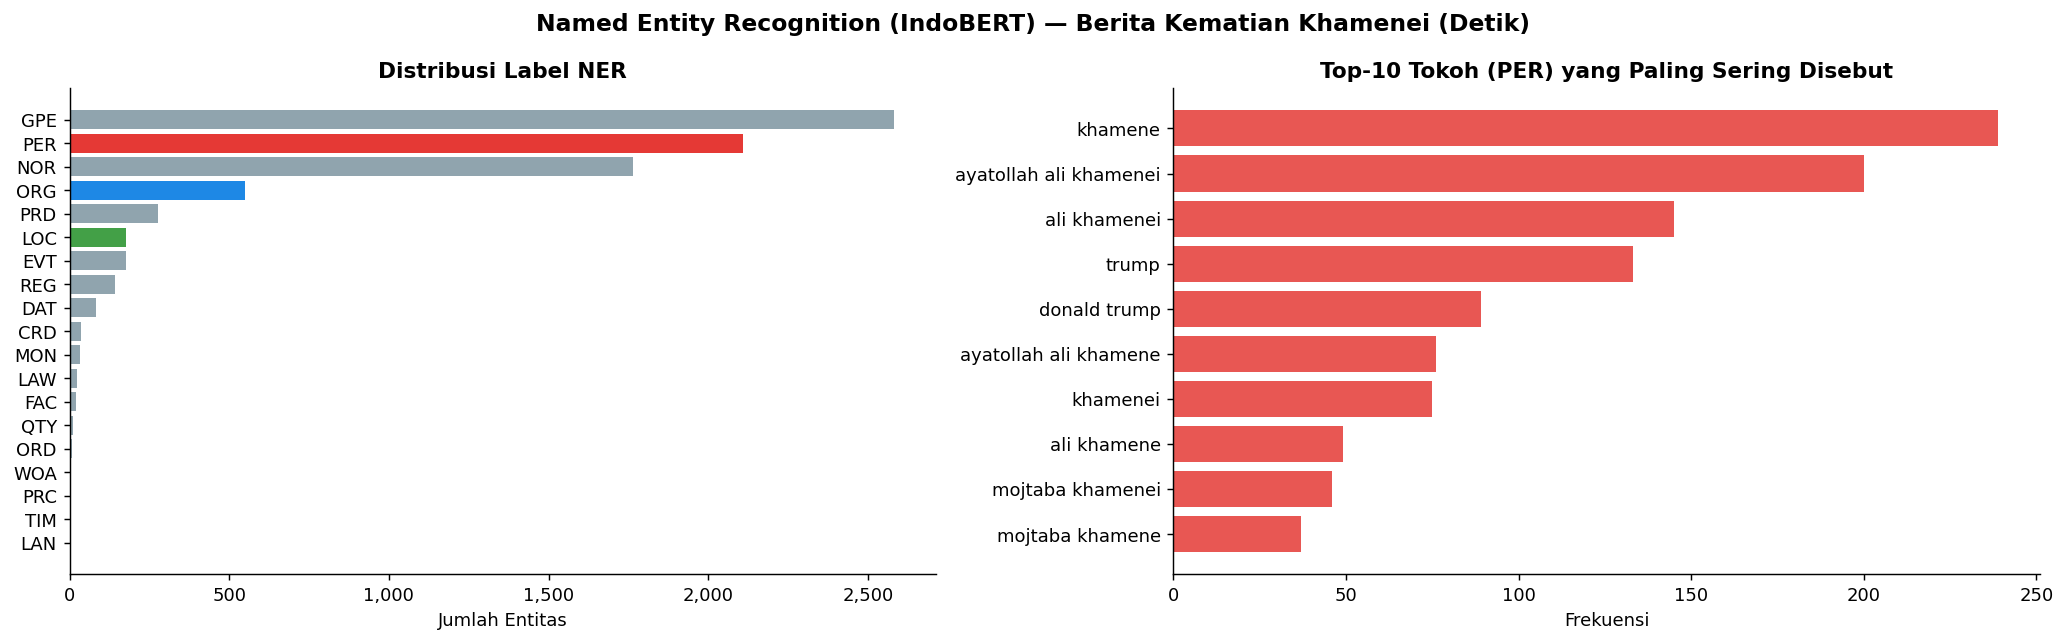

Grafik NER disimpan ke ner_distribution.png


In [ ]:
NER_COLORS = {
    'PER': '#E53935',
    'ORG': '#1E88E5',
    'LOC': '#43A047',
}
DEFAULT_COLOR = '#90A4AE'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Kiri: distribusi label
ax = axes[0]
colors_bar = [NER_COLORS.get(l, DEFAULT_COLOR) for l in ner_summary['Label']]
ax.barh(ner_summary['Label'][::-1], ner_summary['Jumlah_Entitas'][::-1], color=colors_bar[::-1])
ax.set_xlabel('Jumlah Entitas')
ax.set_title('Distribusi Label NER', fontweight='bold')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Kanan: top-10 PER
ax2 = axes[1]
if 'PER' in df_ner['Label'].values:
    per_top = df_ner[df_ner['Label'] == 'PER']['Entitas'].value_counts().head(10).sort_values()
    ax2.barh(per_top.index, per_top.values, color=NER_COLORS['PER'], alpha=0.85)
    ax2.set_xlabel('Frekuensi')
    ax2.set_title('Top-10 Tokoh (PER) yang Paling Sering Disebut', fontweight='bold')
else:
    ax2.set_visible(False)

plt.suptitle('Named Entity Recognition (IndoBERT) — Berita Kematian Khamenei (Detik)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ner_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik NER disimpan ke ner_distribution.png')


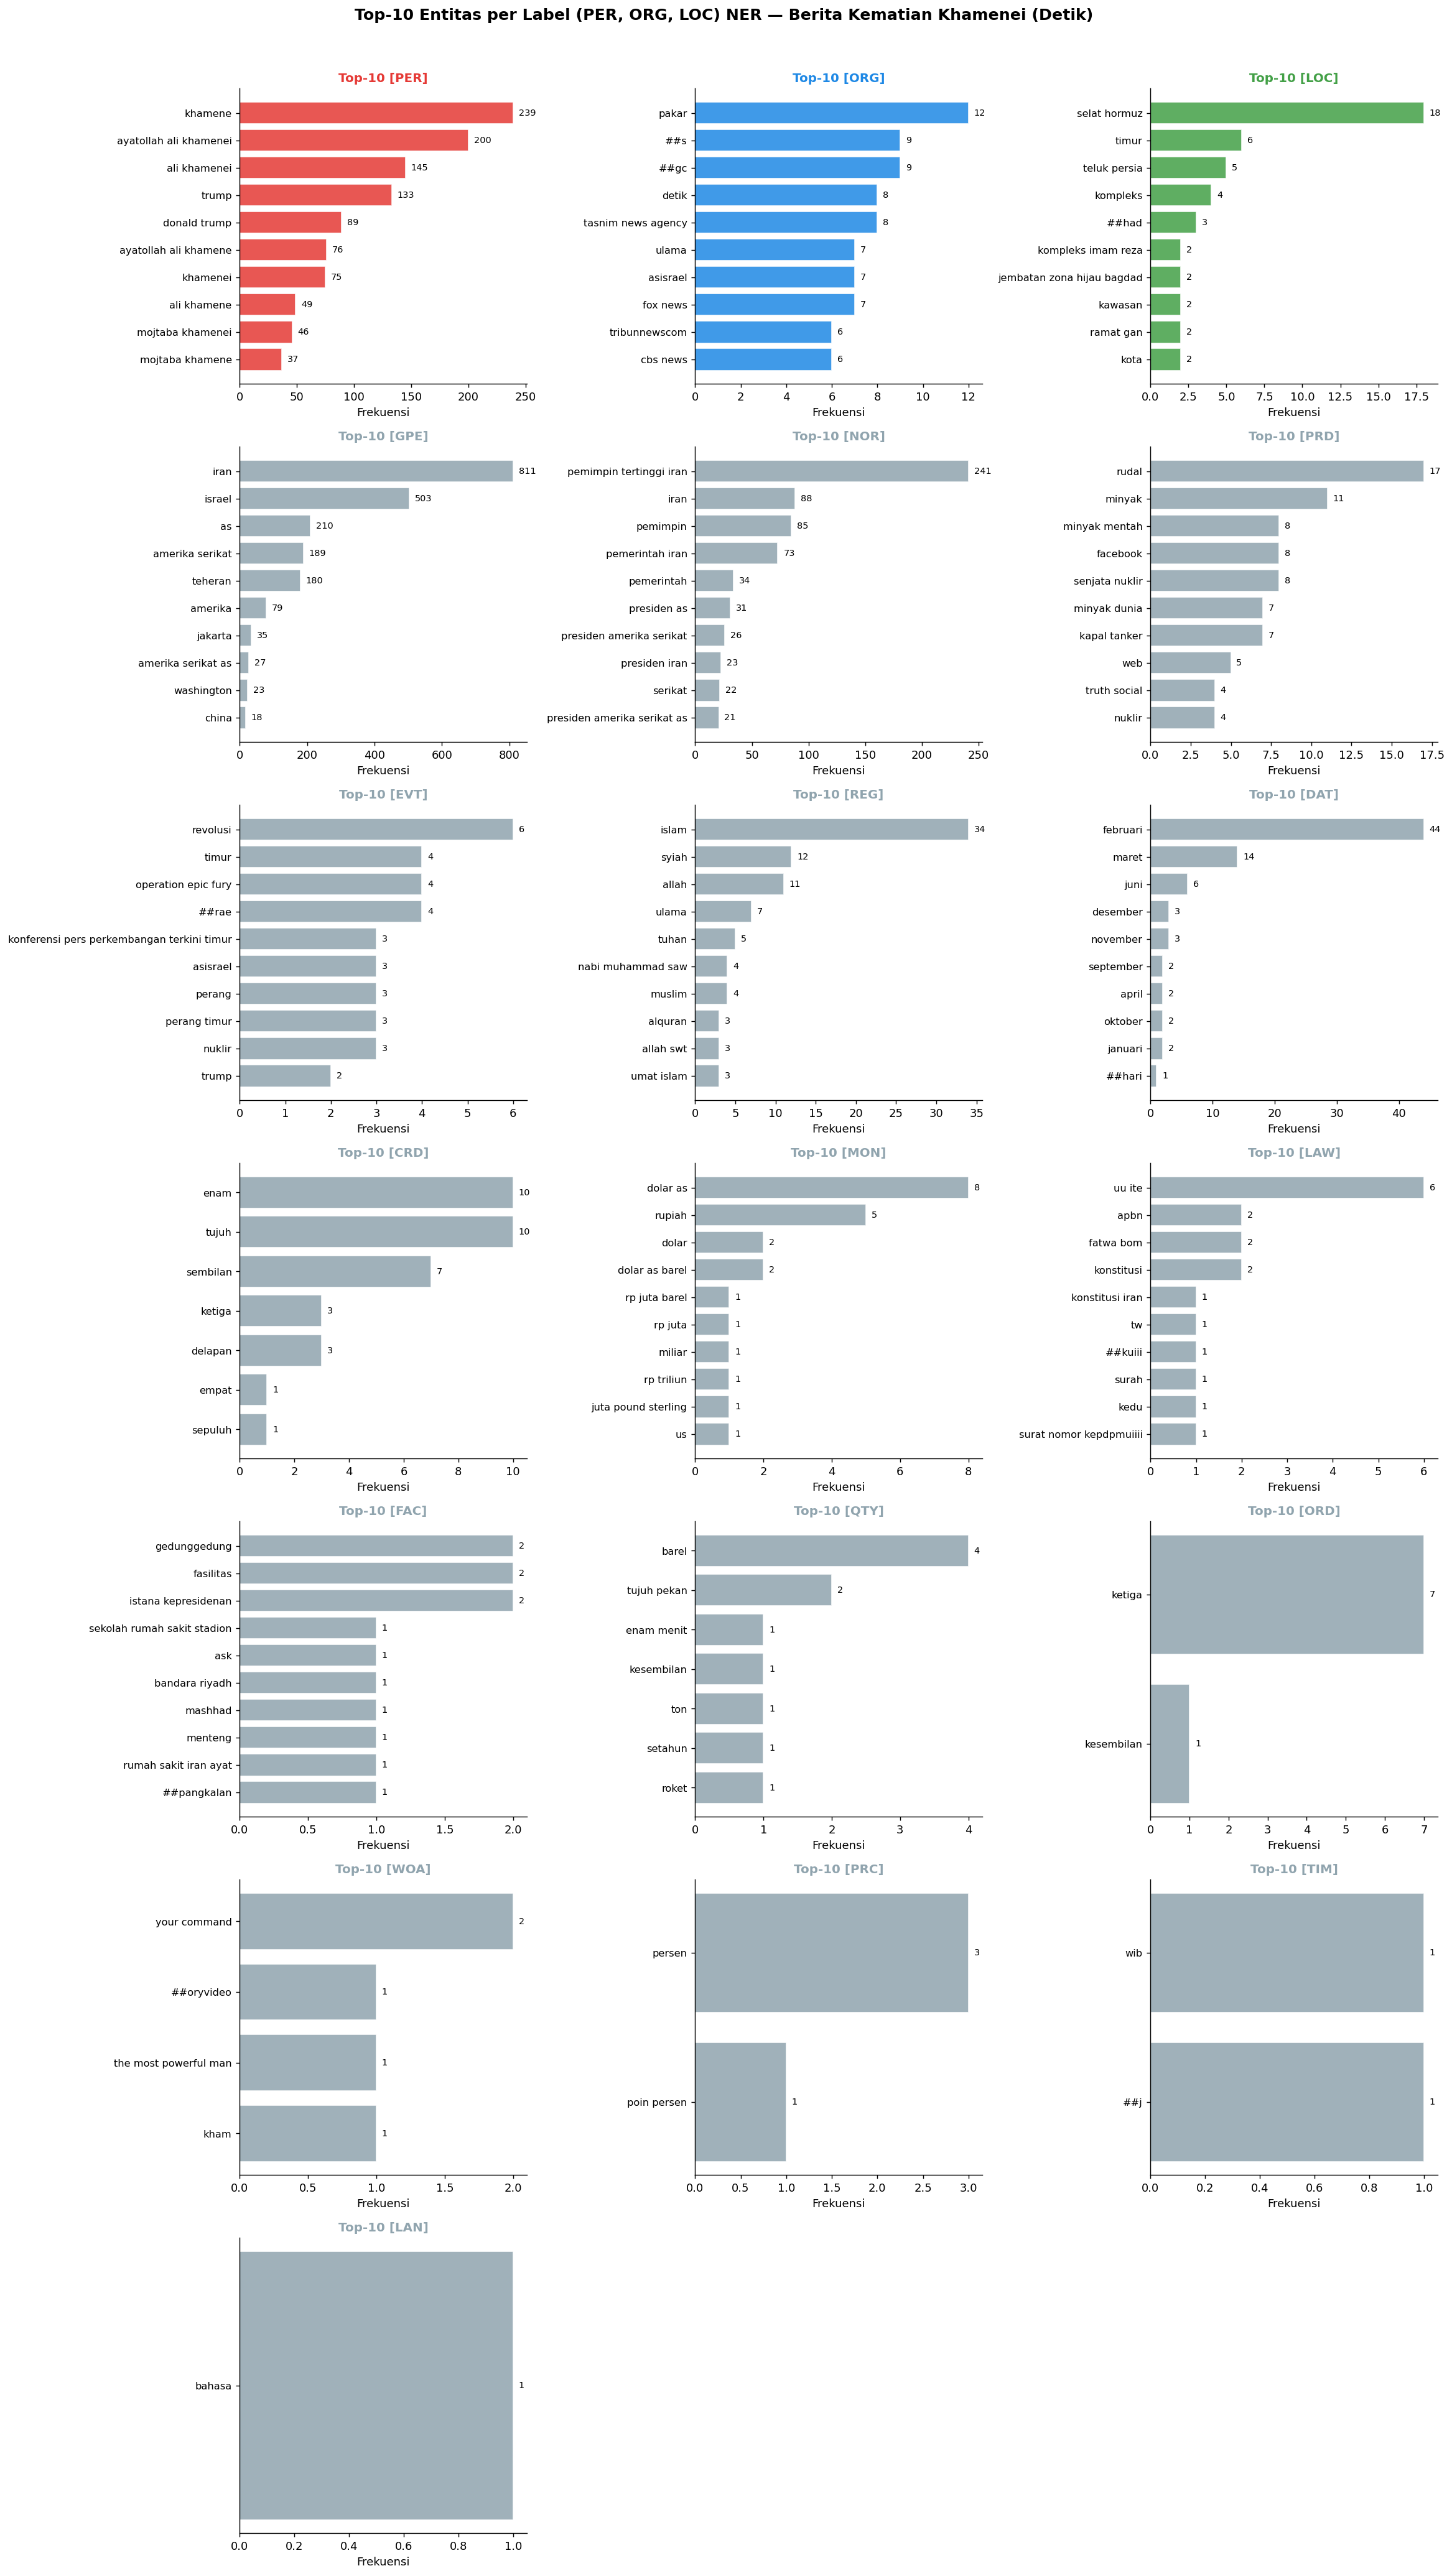

In [ ]:
# 1. Pisahkan dan urutkan label berdasarkan keberadaannya di NER_COLORS
colored_labels = [l for l in ner_summary['Label'].tolist() if l in NER_COLORS]
default_labels = [l for l in ner_summary['Label'].tolist() if l not in NER_COLORS]

# Gabungkan kembali: yang berwarna di awal, sisanya di akhir
labels_to_plot = colored_labels + default_labels

# --- Sisa kode plotting tetap sama ---
ncols_ner = min(3, len(labels_to_plot))
nrows_ner = -(-len(labels_to_plot) // ncols_ner)

fig, axes = plt.subplots(nrows_ner, ncols_ner, figsize=(18, nrows_ner * 4.5))
axes = np.array(axes).flatten()

for i, label in enumerate(labels_to_plot):
    ax = axes[i]
    subset = df_ner[df_ner['Label'] == label]
    top = subset['Entitas'].value_counts().head(10).sort_values()

    if top.empty:
        ax.axis('off') # Menggunakan axis('off') agar lebih bersih jika data kosong
        continue

    color = NER_COLORS.get(label, DEFAULT_COLOR)
    bars = ax.barh(top.index, top.values, color=color, alpha=0.85, edgecolor='white')

    # Penambahan label angka di ujung bar
    max_val = top.values.max()
    for bar, val in zip(bars, top.values):
        ax.text(val + max_val * 0.02,
                bar.get_y() + bar.get_height() / 2,
                str(val), va='center', fontsize=8)

    ax.set_title(f'Top-10 [{label}]', fontweight='bold', color=color, fontsize=11)
    ax.set_xlabel('Frekuensi')
    ax.tick_params(axis='y', labelsize=9)

# Menghilangkan subplot kosong
for j in range(len(labels_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top-10 Entitas per Label (PER, ORG, LOC) NER — Berita Kematian Khamenei (Detik)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ner_top10_per_label.png', dpi=150, bbox_inches='tight')
plt.show()

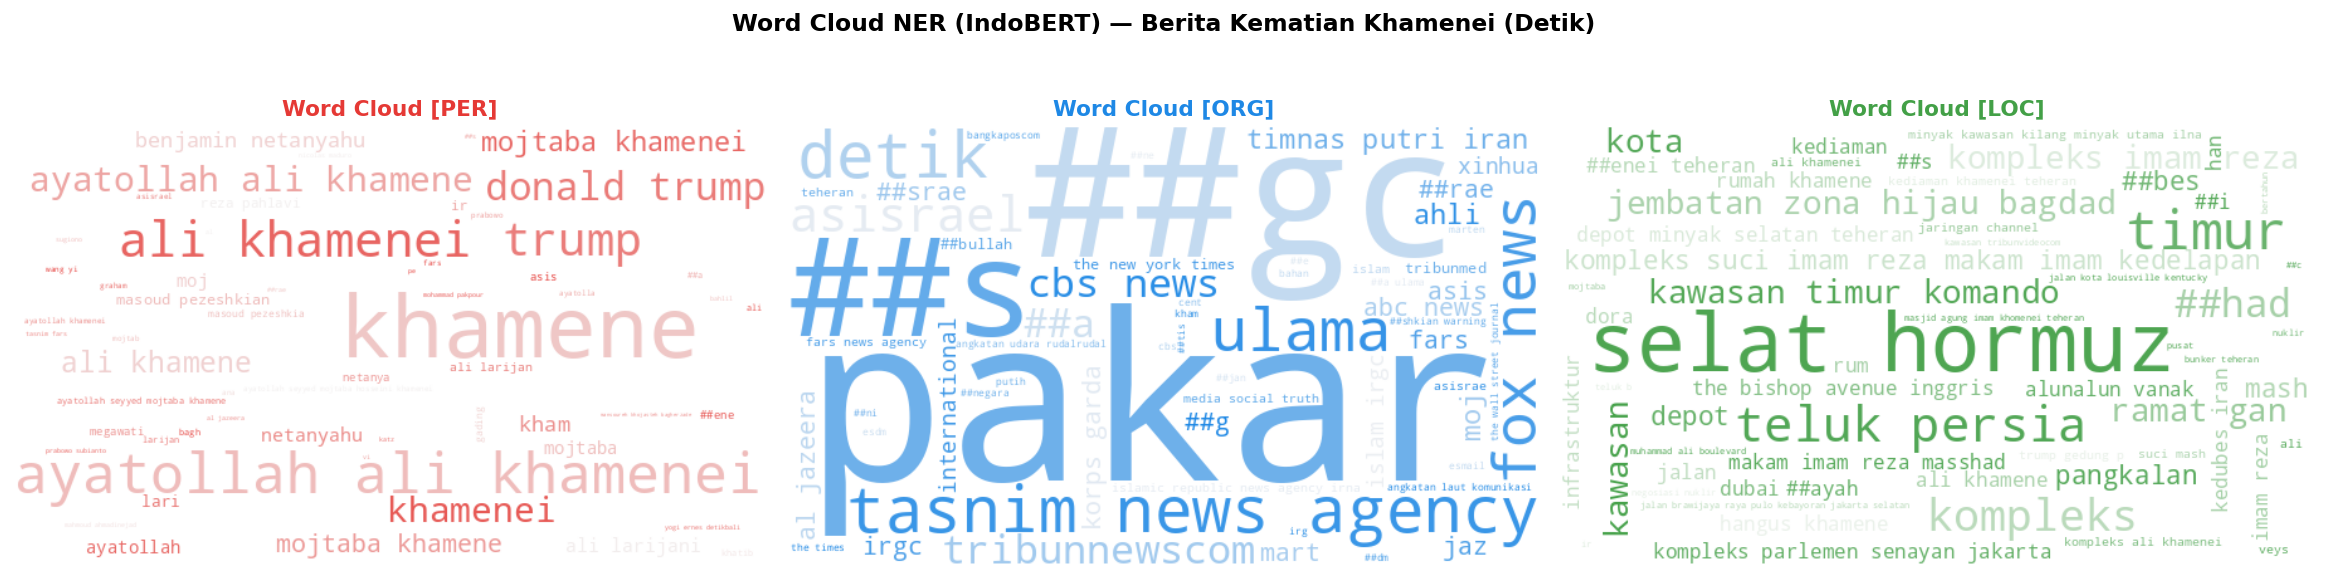

In [ ]:
wc_ner_tags = [l for l in ['PER', 'ORG', 'LOC'] if l in df_ner['Label'].values]

if wc_ner_tags:
    fig, axes = plt.subplots(1, len(wc_ner_tags), figsize=(6 * len(wc_ner_tags), 5))
    if len(wc_ner_tags) == 1:
        axes = [axes]
    for ax, label in zip(axes, wc_ner_tags):
        freq_dict = dict(df_ner[df_ner['Label'] == label]['Entitas'].value_counts())
        color = NER_COLORS.get(label, DEFAULT_COLOR)
        base  = color.lstrip('#')
        r, g, b = tuple(int(base[j:j+2], 16) for j in (0, 2, 4))
        cmap  = sns.light_palette((r/255, g/255, b/255), as_cmap=True, input='rgb')
        wc = WordCloud(
            width=600, height=350, background_color='white',
            colormap=cmap, max_words=60, collocations=False
        ).generate_from_frequencies(freq_dict)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'Word Cloud [{label}]', fontweight='bold', color=color, fontsize=12)
    plt.suptitle('Word Cloud NER (IndoBERT) — Berita Kematian Khamenei (Detik)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('ner_wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()


## **(8) Ekspor Hasil**

- `tagged_articles.csv` — DataFrame lengkap dengan kolom `pos_tags`, `lemma_tags`, dan `ner_tags`
- `pos_tags_summary.csv` — Distribusi POS
- `ner_summary.csv` — Distribusi label NER
- `ner_entities.csv` — Semua entitas yang terdeteksi


In [ ]:
df_export = df_article.copy()
df_export['pos_tags']   = df_export['pos_tags'].apply(str)
df_export['lemma_tags'] = df_export['lemma_tags'].apply(str)
df_export['ner_tags']   = df_export['ner_tags'].apply(str)
df_export.drop(columns=['text_length'], errors='ignore', inplace=True)
df_export.to_csv('tagged_articles.csv', index=False)
print(f'tagged_articles.csv — {len(df_export)} baris')

ner_summary.to_csv('ner_summary.csv', index=False)
print('ner_summary.csv tersimpan.')

df_ner.to_csv('ner_entities.csv', index=False)
print(f'ner_entities.csv — {len(df_ner):,} entitas tersimpan.')


tagged_articles.csv — 491 baris
ner_summary.csv tersimpan.
ner_entities.csv — 8,003 entitas tersimpan.
